In [1]:
import os
import random

import numpy as np

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # mniej komunikatów diagnostycznych TensorFlow
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # powtarzalne wyniki numeryczne na CPU

random.seed(42)
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)
from tensorflow import keras

(train_x, train_y), (test_x, test_y) = keras.datasets.fashion_mnist.load_data()

def loader(features, targets, batchsize: int = 1):
    # FashionMNIST z Keras to obrazy uint8 0..255 o kształcie (N, 28, 28);
    # skalujemy do [0, 1] i dodajemy wymiar kanału -> (N, 28, 28, 1), następnie tasujemy i dzielimy na batche
    x = (features.astype("float32") / 255.0)[..., None]
    ds = tf.data.Dataset.from_tensor_slices((x, targets))
    return ds.shuffle(len(targets)).batch(batchsize)

net = keras.Sequential([
    keras.Input((28, 28, 1)),
    keras.layers.Conv2D(6, 3, padding="same", use_bias=False),    # 54 parametry
    keras.layers.MaxPool2D(2),
    keras.layers.Conv2D(16, 3, padding="same", use_bias=False),   # 864 parametry
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(84, activation="relu"),                    # 65_940 parametrów
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10),                                       # 850 parametrów
])
net.summary()   # łącznie 67_708 parametrów

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        65,940 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,708 (264.48 KB)

 Trainable params: 67,708 (264.48 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
from collections import namedtuple
import numpy as np

def onecold(y):
    # odpowiednik Flux.onecold – zwraca indeks (etykietę) największej wartości
    return tf.argmax(y, axis=1)

x1, y1 = next(iter(loader(train_x, train_y)))
y1hat = net(x1, training=False)
print("hcat(onecold(y1hat), onecold(y1)) =", np.stack([onecold(y1hat).numpy(), y1.numpy()]).T.tolist())

Metrics = namedtuple("Metrics", ["loss", "acc", "split"])

def loss_and_accuracy(model, features, targets, split):
    # przepuszczamy cały zbiór przez sieć (w porcjach, aby oszczędzić pamięć) i liczymy stratę oraz trafność
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader(features, targets, batchsize=1000):
        yhat = model(x, training=False)
        total_loss += float(tf.reduce_sum(keras.losses.sparse_categorical_crossentropy(y, yhat, from_logits=True)))
        correct += int(tf.reduce_sum(tf.cast(onecold(yhat) == tf.cast(y, tf.int64), tf.int32)))
        n += int(x.shape[0])
    loss = total_loss / n
    acc = round(100 * correct / n, 2)
    return Metrics(loss=loss, acc=acc, split=split)

print("loss_and_accuracy(net, test_data) =", loss_and_accuracy(net, test_x, test_y, "test"))  # ok. 10% przed treningiem

train_log = []
settings = dict(
    eta=1e-2,
    epochs=3,
    batchsize=10,
)
opt_state = keras.optimizers.SGD(learning_rate=settings["eta"])
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

hcat(onecold(y1hat), onecold(y1)) = [[7, 3]]
loss_and_accuracy(net, test_data) = Metrics(loss=2.2877538330078124, acc=9.24, split='test')


In [3]:
import time

@tf.function
def train_step(x, y):
    # pojedynczy krok SGD: liczymy gradienty straty po wagach i aktualizujemy parametry
    with tf.GradientTape() as tape:
        loss = loss_fn(y, net(x, training=True))
    grads = tape.gradient(loss, net.trainable_variables)
    opt_state.apply_gradients(zip(grads, net.trainable_variables))

accuracy = np.zeros((settings["epochs"], 2))
for epoch in range(1, settings["epochs"] + 1):
    t0 = time.perf_counter()
    for x, y in loader(train_x, train_y, batchsize=settings["batchsize"]):
        train_step(x, y)
    print(f"{time.perf_counter() - t0:10.6f} seconds")

    loss, acc, _ = loss_and_accuracy(net, train_x, train_y, "train")
    test_loss, test_acc, _ = loss_and_accuracy(net, test_x, test_y, "test")
    print(f"┌ Info: {epoch}\n│   acc = {acc}\n│   test_acc = {test_acc}\n└")
    train_log.append(dict(epoch=epoch, loss=loss, acc=acc, test_loss=test_loss, test_acc=test_acc))
    accuracy[epoch - 1, 0] = acc
    accuracy[epoch - 1, 1] = test_acc

 14.230039 seconds
┌ Info: 1
│   acc = 83.91
│   test_acc = 83.2
└
 13.026576 seconds
┌ Info: 2
│   acc = 85.0
│   test_acc = 83.9
└
 13.150322 seconds
┌ Info: 3
│   acc = 87.36
│   test_acc = 86.28
└


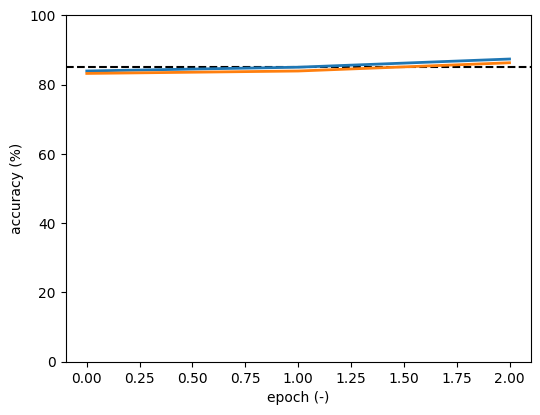

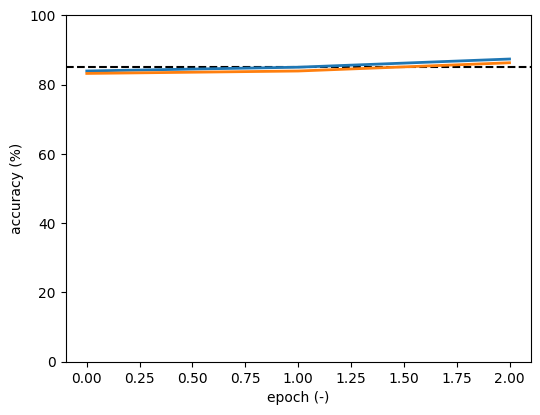

In [4]:
import matplotlib.pyplot as plt

fig, gca = plt.subplots(figsize=(6, 4.5))
gca.set_xlabel("epoch (-)")
gca.set_ylabel("accuracy (%)")
gca.axhline(85, linestyle="--", color="black")
gca.plot(accuracy[:, 0], linewidth=2)
gca.plot(accuracy[:, 1], linewidth=2)
gca.set_ylim(0, 100)
fig

In [5]:
x1, y1 = next(iter(loader(test_x, test_y)))
y1hat = net(x1, training=False)
print("hcat(onecold(y1hat), onecold(y1)) =", np.stack([onecold(y1hat).numpy(), y1.numpy()]).T.tolist())
print("loss_and_accuracy(net, test_data) =", loss_and_accuracy(net, test_x, test_y, "test"))

hcat(onecold(y1hat), onecold(y1)) = [[1, 1]]
loss_and_accuracy(net, test_data) = Metrics(loss=0.37465765075683594, acc=86.28, split='test')


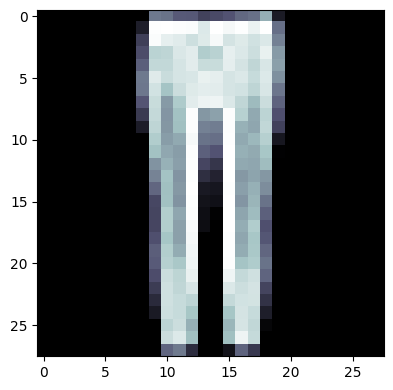

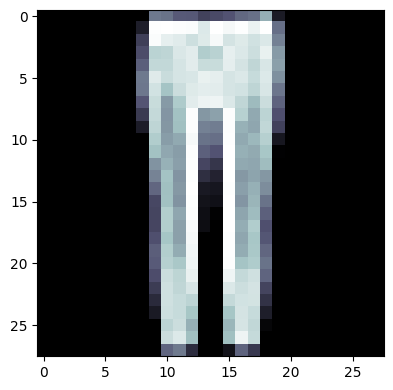

In [6]:
# pojedynczy obraz z batcha (kanał 0) wyświetlony jako mapa cieplna w odcieniach szarości
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.imshow(x1[0, :, :, 0].numpy(), cmap="bone")
ax.set_aspect("equal")
fig